# Sales Forecasting — Baseline
**Goal:** Predict daily `Revenue` and `COGS` for 2023-01-01 → 2024-07-01 using historical data (2012–2022).

**Strategy (simple seasonal average + trend):**
1. Compute average YoY growth rate from 2013–2022.
2. Build a "seasonal profile" — the average Revenue/COGS for each calendar day-of-year across all historical years.
3. Scale the profile by the projected year-level trend to produce predictions.

## 1 — Imports & Config

In [1]:
import sys
print(sys.executable)

c:\Users\reust\OneDrive\datathon-vinuni\.venv\Scripts\python.exe


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

DATA_DIR  = 'dataset/'
TRAIN_FILE = DATA_DIR + 'sales.csv'
OUT_FILE   = DATA_DIR + 'submission.csv'

In [3]:
import pandas as pd

df = pd.read_csv("customers.csv")
df.head()

,customer_id,zip,city,signup_date,gender,age_group,acquisition_channel
0,1,15201,Hai Phong,2021-12-30,Female,35-44,social_media
1,2,15201,Hai Phong,2013-12-27,Female,45-54,email_campaign
2,3,15201,Hai Phong,2018-07-24,Female,18-24,organic_search
3,4,15201,Hai Phong,2017-11-29,Male,35-44,referral
4,5,15201,Hai Phong,2022-09-23,Male,55+,organic_search


## 2 — Load & Inspect Data

In [4]:
sub = pd.read_csv("sample_submission.csv")
sub.head()

,Date,Revenue,COGS
0,2023-01-01,2665507.20,2518885.15
1,2023-01-02,1280007.89,1136463.00
2,2023-01-03,1015899.51,822721.12
3,2023-01-04,1142997.27,914554.18
4,2023-01-05,1236312.34,984390.24


In [41]:
customers = pd.read_csv("customers.csv")
orders = pd.read_csv("orders.csv")
order_items = pd.read_csv("order_items.csv")
payments = pd.read_csv("payments.csv")
products = pd.read_csv("products.csv")
sales =pd.read_csv('sales.csv')
geography =pd.read_csv('geography.csv')
returns =pd.read_csv('returns.csv')

In [ ]:
customers.info()
orders.info()
order_items.info()
payments.info()
products.info()
sales.info()
geography.info()


<class 'pandas.DataFrame'>
RangeIndex: 121930 entries, 0 to 121929
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype
---  ------               --------------   -----
 0   customer_id          121930 non-null  int64
 1   zip                  121930 non-null  int64
 2   city                 121930 non-null  str  
 3   signup_date          121930 non-null  str  
 4   gender               121930 non-null  str  
 5   age_group            121930 non-null  str  
 6   acquisition_channel  121930 non-null  str  
dtypes: int64(2), str(5)
memory usage: 6.5 MB
<class 'pandas.DataFrame'>
RangeIndex: 646945 entries, 0 to 646944
Data columns (total 8 columns):
 #   Column          Non-Null Count   Dtype
---  ------          --------------   -----
 0   order_id        646945 non-null  int64
 1   order_date      646945 non-null  str  
 2   customer_id     646945 non-null  int64
 3   zip             646945 non-null  int64
 4   order_status    646945 non-null  str  
 5   pa

In [7]:
train = pd.read_csv('sales.csv', parse_dates=['Date'])
test  = pd.read_csv('sample_submission.csv',  parse_dates=['Date'])

print('Train shape:', train.shape)
print('Train date range:', train['Date'].min().date(), '→', train['Date'].max().date())
print()
print('Test shape:', test.shape)
print('Test date range:', test['Date'].min().date(), '→', test['Date'].max().date())
print()
train.tail()

Train shape: (3833, 3)
Train date range: 2012-07-04 → 2022-12-31

Test shape: (548, 3)
Test date range: 2023-01-01 → 2024-07-01



,Date,Revenue,COGS
3828,2022-12-27,2100553.66,2184872.24
3829,2022-12-28,3448729.20,3513621.00
3830,2022-12-29,3083944.33,3170787.10
3831,2022-12-30,2884668.76,3022292.15
3832,2022-12-31,2383037.48,2279288.13


In [8]:
train = train.sort_values('Date')

In [9]:
print(type(train))

<class 'pandas.DataFrame'>


In [10]:
#Check Duplicates, outliers
print("Duplicate Dates:", train['Date'].duplicated().sum())
print(train.isnull().sum())
date_diff = train['Date'].diff().value_counts()
print(date_diff.head())
print(train[['Revenue', 'COGS']].describe())
print("Revenue < 0:", (train['Revenue'] < 0).sum())
print("COGS < 0:", (train['COGS'] < 0).sum())
yearly = train.groupby(train['Date'].dt.year)['Revenue'].sum()
print(yearly)


      


Duplicate Dates: 0
Date       0
Revenue    0
COGS       0
dtype: int64
Date
1 days    3832
Name: count, dtype: int64
            Revenue          COGS
count  3.833000e+03  3.833000e+03
mean   4.286584e+06  3.695134e+06
std    2.624840e+06  2.219789e+06
min    2.798139e+05  2.365763e+05
25%    2.471089e+06  2.150580e+06
50%    3.647304e+06  3.161113e+06
75%    5.350877e+06  4.637294e+06
max    2.090527e+07  1.653586e+07
Revenue < 0: 0
COGS < 0: 0
Date
2012    7.414977e+08
2013    1.657169e+09
2014    1.871846e+09
2015    1.889934e+09
2016    2.104641e+09
2017    1.911164e+09
2018    1.850122e+09
2019    1.136801e+09
2020    1.054512e+09
2021    1.043040e+09
2022    1.169749e+09
Name: Revenue, dtype: float64


## 3 — Feature Engineering

In [11]:
#change date to datetime
train['Date'] = pd.to_datetime(train['Date'])


In [12]:
#Adding features
train['year']  = train['Date'].dt.year
train['day_of_year'] = train['Date'].dt.dayofyear
train['month']      = train['Date'].dt.month
train['day_of_week'] = train['Date'].dt.day_name()

# Annual totals used to estimate YoY growth
annual = train.groupby('year')[['Revenue', 'COGS']].sum()
print('Annual totals (only complete years shown):')
print(annual)

Annual totals (only complete years shown):
           Revenue          COGS
year                            
2012  7.414977e+08  5.874619e+08
2013  1.657169e+09  1.465980e+09
2014  1.871846e+09  1.574607e+09
2015  1.889934e+09  1.665442e+09
2016  2.104641e+09  1.780559e+09
2017  1.911164e+09  1.694386e+09
2018  1.850122e+09  1.542176e+09
2019  1.136801e+09  1.005203e+09
2020  1.054512e+09  8.860851e+08
2021  1.043040e+09  9.411301e+08
2022  1.169749e+09  1.020420e+09


In [13]:
print(train.dtypes)
print(train.describe())
print(train.isna().sum())

Date           datetime64[us]
Revenue               float64
COGS                  float64
year                    int32
day_of_year             int32
month                   int32
day_of_week               str
dtype: object
                      Date       Revenue          COGS         year  \
count                 3833  3.833000e+03  3.833000e+03  3833.000000   
mean   2017-10-02 00:00:00  4.286584e+06  3.695134e+06  2017.240543   
min    2012-07-04 00:00:00  2.798139e+05  2.365763e+05  2012.000000   
25%    2015-02-17 00:00:00  2.471089e+06  2.150580e+06  2015.000000   
50%    2017-10-02 00:00:00  3.647304e+06  3.161113e+06  2017.000000   
75%    2020-05-17 00:00:00  5.350877e+06  4.637294e+06  2020.000000   
max    2022-12-31 00:00:00  2.090527e+07  1.653586e+07  2022.000000   
std                    NaN  2.624840e+06  2.219789e+06     3.036754   

       day_of_year        month  
count  3833.000000  3833.000000  
mean    187.487086     6.665797  
min       1.000000     1.000000  


In [14]:
train.head()


,Date,Revenue,COGS,year,day_of_year,month,day_of_week
0,2012-07-04,5123547.94,3982991.19,2012,186,7,Wednesday
1,2012-07-05,2751773.45,2150580.23,2012,187,7,Thursday
2,2012-07-06,3054029.42,2517632.84,2012,188,7,Friday
3,2012-07-07,2667930.94,2108246.62,2012,189,7,Saturday
4,2012-07-08,2360851.90,1808622.79,2012,190,7,Sunday


Some Sales Insights from sales.csv


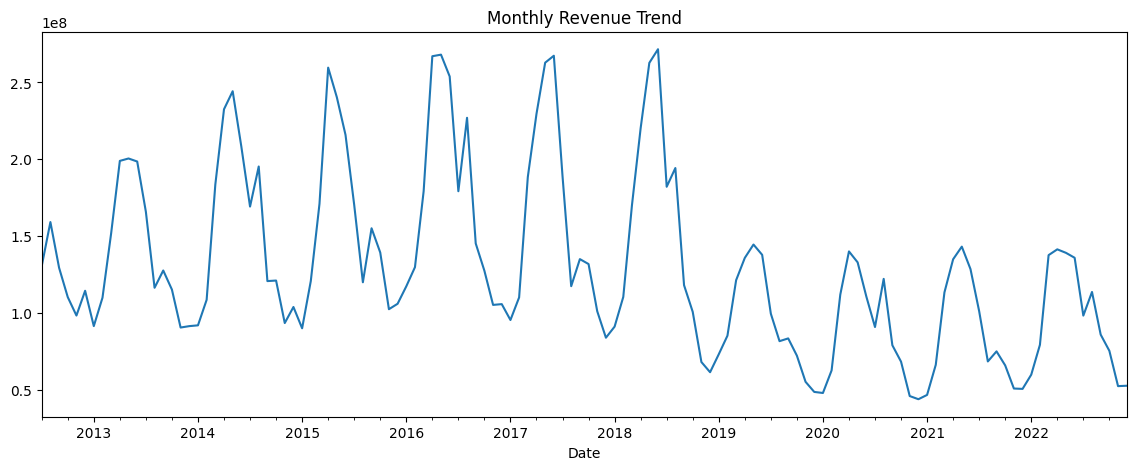

In [15]:
# aggregation
monthly = train.resample('ME', on='Date').agg({
    'Revenue': 'sum',
    'COGS': 'sum'
})

# features 
monthly['Profit'] = monthly['Revenue'] - monthly['COGS']
monthly['Margin'] = monthly['Profit'] / monthly['Revenue']

# plot
monthly['Revenue'].plot(figsize=(14,5), title='Monthly Revenue Trend')
plt.show()

#Insight
 Seasonality shows strong consistent upward trends between 2013-2018 period, but there is a sharp decline after 2018 period,representing a potential business downturn, or some economics change.

<Axes: xlabel='day_of_week', ylabel='Revenue'>

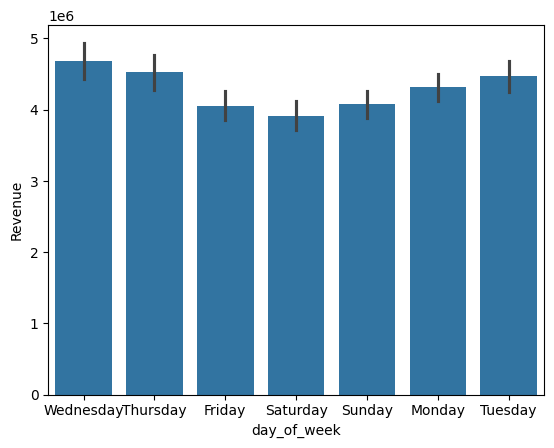

In [16]:
# day-of-week performance

import seaborn as sns
sns.barplot(x='day_of_week', y='Revenue', data=train)

<Axes: xlabel='month', ylabel='Revenue'>

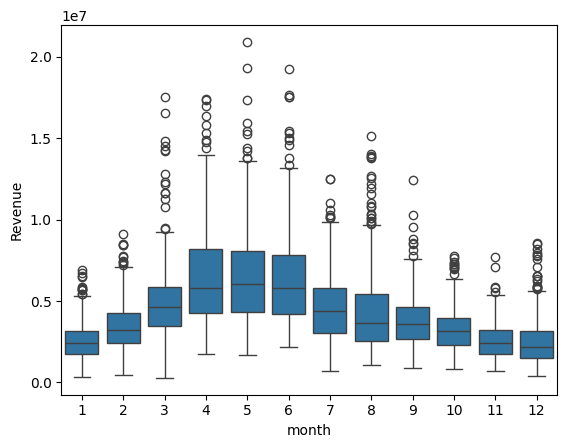

In [17]:
#Monthly performance
train['month'] = train['Date'].dt.month

sns.boxplot(x='month', y='Revenue', data=train)

<Axes: xlabel='month', ylabel='day_of_week'>

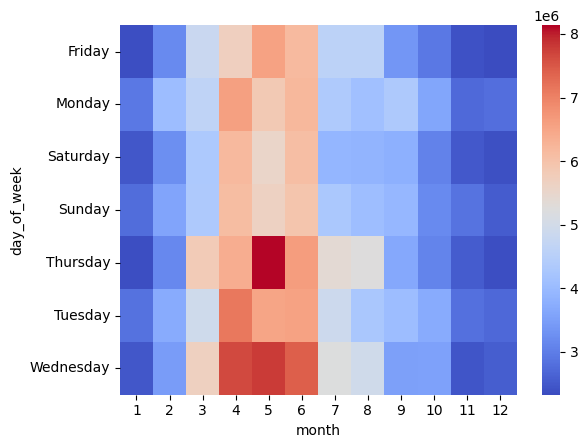

In [18]:
pivot = train.pivot_table(
    values='Revenue',
    index='day_of_week',
    columns='month',
    aggfunc='mean'
)

sns.heatmap(pivot, cmap='coolwarm')

In [19]:
# --- YoY growth rate (geometric mean, 2013–2022) ---
# Use years with full data: 2013 to 2022
full_years = annual.loc[2013:2022]

yoy_rev  = full_years['Revenue'].pct_change().dropna()
yoy_cogs = full_years['COGS'].pct_change().dropna()

growth_rev  = (1 + yoy_rev).prod() ** (1 / len(yoy_rev))
growth_cogs = (1 + yoy_cogs).prod() ** (1 / len(yoy_cogs))

print(f'Geometric mean YoY Revenue growth : {growth_rev:.4f}  ({(growth_rev-1)*100:.2f}%/yr)')
print(f'Geometric mean YoY COGS    growth : {growth_cogs:.4f}  ({(growth_cogs-1)*100:.2f}%/yr)')

Geometric mean YoY Revenue growth : 0.9620  (-3.80%/yr)
Geometric mean YoY COGS    growth : 0.9605  (-3.95%/yr)


Part 1: Multiple Choice Question

Q6. Trong customers.csv, xét các khách hàng có age_group khác null, nhóm tuổi nào có số
đơn hàng trung bình trên mỗi khách hàng cao nhất? (tổng số đơn / số khách hàng trong
nhóm)

In [20]:
#Join data
df =orders.merge (customers, on='customer_id',how= 'left')
orders_per_customer =df.groupby ('customer_id').size().reset_index (name ='num_orders')
print(orders_per_customer)


       customer_id  num_orders
0                1           6
1                2           4
2                3           3
3                4           1
4                5           5
...            ...         ...
90241       157554           1
90242       157555           2
90243       157557           1
90244       157561          22
90245       157563          22

[90246 rows x 2 columns]


In [21]:
orders_per_customer =orders_per_customer.merge(customers[['customer_id','age_group']],on='customer_id',how='left')
print(orders_per_customer)

       customer_id  num_orders age_group
0                1           6     35-44
1                2           4     45-54
2                3           3     18-24
3                4           1     35-44
4                5           5       55+
...            ...         ...       ...
90241       157554           1     18-24
90242       157555           2     25-34
90243       157557           1     45-54
90244       157561          22     45-54
90245       157563          22     35-44

[90246 rows x 3 columns]


In [22]:
#Filter null 
orders_per_customer =orders_per_customer[orders_per_customer['age_group'].notna()]
result = orders_per_customer.groupby ('age_group')['num_orders'].mean().sort_values(ascending=False)
print(result)

age_group
55+      7.268731
45-54    7.220264
35-44    7.206159
25-34    7.112230
18-24    7.068577
Name: num_orders, dtype: float64


Q7:Vùng (region) nào trong geography.csv tạo ra tổng doanh thu cao nhất trong
sales_train.csv?


In [23]:
print(type(geography))
geography.head()

<class 'pandas.DataFrame'>


,zip,city,region,district
0,15201,Hai Phong,East,District #13
1,15202,Phu Ly,East,District #13
2,15203,Viet Tri,East,District #13
3,15204,Bac Giang,East,District #13
4,15205,Bac Giang,East,District #13


In [24]:
df =order_items.merge(orders,on ='order_id',how ='left')
df = df.merge (geography,on ='zip',how='left')

df['revenue'] =df['quantity']* df['unit_price']

result_q7 =df.groupby('region')['revenue'].sum().sort_values (ascending=False)
print(result_q7)


region
East       7.637533e+09
Central    4.941908e+09
West       3.851035e+09
Name: revenue, dtype: float64


Q8. Trong các đơn hàng có order_status = ’cancelled’ trong orders.csv, phương thức
thanh toán nào được sử dụng nhiều nhất?


In [28]:
cancelled_orders =orders[orders['order_status'] == 'cancelled']
print(cancelled_orders.shape)
cancelled_orders.head()

(59462, 8)


,order_id,order_date,customer_id,zip,order_status,payment_method,device_type,order_source
16,22,2012-07-06,12621,10019,cancelled,apple_pay,desktop,organic_search
20,26,2012-07-05,16344,13502,cancelled,credit_card,desktop,paid_search
24,31,2012-07-06,59,15212,cancelled,cod,mobile,email_campaign
33,42,2012-07-06,48406,19977,cancelled,paypal,mobile,direct
37,46,2012-07-04,68317,24141,cancelled,cod,desktop,paid_search


In [32]:
df = cancelled_orders.merge (payments, on ='order_id',how ='left')
result_q8 =df['payment_method_x'].value_counts()
print(result_q8)

payment_method_x
credit_card      28452
cod              15468
paypal            7817
apple_pay         5190
bank_transfer     2535
Name: count, dtype: int64


Q9. Trong bốn kích thước sản phẩm (S, M, L, XL), kích thước nào có tỷ lệ trả hàng cao
nhất, được định nghĩa là số bản ghi trong returns chia cho số dòng trong order_items (join
với products theo product_id)?

In [36]:
df_items = order_items.merge (products, on='product_id',how ='left')
df_items.head()

,order_id,product_id,quantity,unit_price,discount_amount,promo_id,promo_id_2,product_name,category,segment,size,color,price,cogs
0,1,2400,7,1138.22,0.0,NaN,NaN,VietMotion YY-09,GenZ,Trendy,S,red,1109.261061,1053.798008
1,2,609,7,10166.25,0.0,NaN,NaN,SaigonFlex UC-74,Streetwear,Everyday,M,yellow,10426.571034,8987.704231
2,3,396,3,11220.33,0.0,NaN,NaN,SaigonFlex UM-01,Streetwear,Balanced,S,green,11028.428695,10091.012256
3,4,635,5,10639.25,0.0,NaN,NaN,SaigonFlex UC-00,Streetwear,Everyday,XL,purple,10745.220588,9205.430478
4,6,1935,1,1597.84,0.0,NaN,NaN,UrbanVN RP-10,Outdoor,Activewear,XL,purple,1609.911509,1048.696357


In [37]:
#count total order_size by size 
total_items = df_items.groupby('size').size()
print(total_items)

size
L     173174
M     176428
S     172042
XL    193025
dtype: int64


In [42]:
# merge size for returns
df_returns =returns.merge(products, on='product_id',how ='left')


In [43]:
#count the return by size
returns_count =df_returns.groupby('size').size()
print(returns_count)

size
L      9741
M      9820
S      9723
XL    10655
dtype: int64


In [44]:
#return rate
return_rate =(returns_count/total_items).sort_values(ascending=False)
print(return_rate)

size
S     0.056515
L     0.056250
M     0.055660
XL    0.055200
dtype: float64


answer:A

Q10. Trong payments.csv, kế hoạch trả góp nào có giá trị thanh toán trung bình trên
mỗi đơn hàng cao nhất?

In [46]:
result_q10 = payments.groupby('installments')['payment_value'].mean().sort_values (ascending=False)
print(result_q10)

installments
6     24446.654403
3     24399.635486
12    24245.772694
1     24113.274166
2       708.473729
Name: payment_value, dtype: float64


Answer: D

## 4 — Build Seasonal Profile

Average Revenue / COGS by **(month, day)** across all available years. This captures seasonal patterns while smoothing out year-specific noise.

In [25]:
# Normalise each year so seasonal profile is scale-free
annual_means = train.groupby('year')[['Revenue','COGS']].transform('mean')
train['rev_norm']  = train['Revenue'] / annual_means['Revenue']
train['cogs_norm'] = train['COGS']    / annual_means['COGS']

# Average normalised value for each (month, day)
seasonal = (
    train
    .groupby(['month', 'day'])[['rev_norm', 'cogs_norm']]
    .mean()
    .reset_index()
)

print('Seasonal profile rows:', len(seasonal))
seasonal.head(10)

KeyError: 'day'

## 5 — Predict Test Period

In [ ]:
# Base level: 2022 annual mean (most recent complete year)
base_rev  = annual.loc[2022, 'Revenue']  / 365
base_cogs = annual.loc[2022, 'COGS']     / 365

# How many years ahead of 2022 is each test date?
test = test.copy()
test['month'] = test['Date'].dt.month
test['day']   = test['Date'].dt.day
test['year']  = test['Date'].dt.year
test['years_ahead'] = test['year'] - 2022

# Merge seasonal profile
test = test.merge(seasonal, on=['month', 'day'], how='left')

# Fill any missing day (e.g. Feb-29 in non-leap years) with 1.0
test['rev_norm']  = test['rev_norm'].fillna(1.0)
test['cogs_norm'] = test['cogs_norm'].fillna(1.0)

# Predicted value = base_level × growth^years_ahead × seasonal_factor
test['Revenue_pred'] = (base_rev  * growth_rev**test['years_ahead']  * test['rev_norm'] ).round(2)
test['COGS_pred']    = (base_cogs * growth_cogs**test['years_ahead'] * test['cogs_norm']).round(2)

print('Predictions sample:')
test[['Date','Revenue_pred','COGS_pred']].head(10)

## 6 — Evaluate on Training Tail (2021–2022)

Quick sanity-check: apply the same method on the last 2 years of training data and measure MAPE.

In [ ]:
val = train[train['year'].isin([2021, 2022])].copy()
val = val.merge(seasonal, on=['month', 'day'], how='left')
val['rev_norm']  = val['rev_norm'].fillna(1.0)
val['cogs_norm'] = val['cogs_norm'].fillna(1.0)
val['years_ahead'] = val['year'] - 2022  # negative for historical
val['Revenue_pred'] = base_rev  * growth_rev**val['years_ahead']  * val['rev_norm']
val['COGS_pred']    = base_cogs * growth_cogs**val['years_ahead'] * val['cogs_norm']

def mape(actual, pred):
    return (np.abs(actual - pred) / actual).mean() * 100

print(f'MAPE Revenue (2021–2022): {mape(val["Revenue"], val["Revenue_pred"]):.2f}%')
print(f'MAPE COGS    (2021–2022): {mape(val["COGS"],    val["COGS_pred"]):.2f}%')

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(val['Date'], val['Revenue'],      lw=0.8, label='Actual')
ax.plot(val['Date'], val['Revenue_pred'], lw=0.8, linestyle='--', label='Predicted')
ax.set_title('Revenue — Actual vs Predicted (2021–2022 validation)')
ax.legend(); plt.tight_layout(); plt.show()

## 7 — Export Submission

In [ ]:
submission = test[['Date', 'Revenue_pred', 'COGS_pred']].rename(
    columns={'Revenue_pred': 'Revenue', 'COGS_pred': 'COGS'}
)
submission['Date'] = submission['Date'].dt.strftime('%Y-%m-%d')
submission.to_csv(OUT_FILE, index=False)

print(f'Saved {len(submission)} rows to {OUT_FILE}')
submission.head(10)